In [27]:

import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import optuna
import lightgbm as lgb

# ---------- Paths ----------
NOTEBOOK_DIR = Path.cwd()
try:
    OUT = OUTPUT_DIR  # if defined earlier in your session
except NameError:
    OUT = NOTEBOOK_DIR.parents[1] / "processed"

TRAIN_FILE = OUT / "train_timesplit.csv"

ARTIFACTS = (NOTEBOOK_DIR.parents[1] / "backend" / "models" / "artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
target = "y_10d_price"             # or 'y_10d_log_return'
id_time_cols = ["id","name","symbol","lastTradedTime"]
valid_frac = 0.1
n_trials = 50
seed = 42

# Optional feature list file created earlier
FEATURE_LIST_FILE = OUT / "artifacts" / "selected_feature_columns.csv"
use_saved_feature_list = FEATURE_LIST_FILE.exists()

# ---------- Load TRAIN ----------
train_df = pd.read_csv(TRAIN_FILE)
if "lastTradedTime" in train_df.columns:
    train_df["lastTradedTime"] = pd.to_datetime(train_df["lastTradedTime"], errors="coerce")

# ---------- Build features ----------
other_targets = [c for c in train_df.columns if c.startswith("y_10d_") and c != target]
exclude = set(id_time_cols + [target] + other_targets)

if use_saved_feature_list:
    X_cols = pd.read_csv(FEATURE_LIST_FILE)["feature"].tolist()
else:
    cand = train_df.drop(columns=[c for c in exclude if c in train_df.columns], errors="ignore")
    X_cols = cand.select_dtypes(include=[np.number]).columns.tolist()

missing = [c for c in X_cols if c not in train_df.columns]
if missing:
    raise KeyError(f"Missing features in train: {missing}")

# ---------- Time-aware internal validation (tail slice) ----------
def tail_validation(df, frac=0.1):
    parts_tr, parts_va = [], []
    for sym, g in df.groupby("symbol", group_keys=False):
        g = g.sort_values("lastTradedTime")
        cut = max(1, int(len(g) * (1 - frac)))
        parts_tr.append(g.iloc[:cut])
        parts_va.append(g.iloc[cut:])
    return pd.concat(parts_tr).reset_index(drop=True), pd.concat(parts_va).reset_index(drop=True)

train_fit_df, valid_df = tail_validation(train_df, valid_frac)

X_train = train_fit_df[X_cols].to_numpy()
y_train = train_fit_df[target].to_numpy()
X_valid = valid_df[X_cols].to_numpy()
y_valid = valid_df[target].to_numpy()

# ---------- Optuna tuning (using the validation slice only for tuning) ----------
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "random_state": seed,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 512),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 400),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "n_estimators": 5000,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
    )
    return model.best_score_["valid_0"]["rmse"]

study = optuna.create_study(direction="minimize", study_name="lgbm_timeseries")
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_params = study.best_params.copy()
best_params.update({
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "random_state": seed,
    "n_estimators": 5000,
})
print("Best params:", best_params)

# ---------- Final training on FULL TRAIN (no test used) ----------
X_full = train_df[X_cols].to_numpy()
y_full = train_df[target].to_numpy()

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_full, y_full,
    eval_set=[(X_valid, y_valid)],  # keep prior valid for early stopping reference only
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
)

# ---------- Save artifacts ----------
joblib.dump(final_model, ARTIFACTS / "model_lightgbm_optuna.joblib")
pd.Series(X_cols, name="feature").to_csv(ARTIFACTS / "feature_columns.csv", index=False)

print(" Training complete.")
print("Model saved:", ARTIFACTS / "model_lightgbm_optuna.joblib")
print("Feature list saved:", ARTIFACTS / "feature_columns.csv")


[I 2025-10-23 13:35:46,101] A new study created in memory with name: lgbm_timeseries
[I 2025-10-23 13:35:57,742] Trial 0 finished with value: 29.959210538478697 and parameters: {'learning_rate': 0.019746067306444477, 'num_leaves': 467, 'max_depth': 8, 'min_child_samples': 277, 'feature_fraction': 0.5535050054406889, 'bagging_fraction': 0.5362566731538448, 'bagging_freq': 7, 'lambda_l1': 0.0019269400805263235, 'lambda_l2': 0.0005732560285599294, 'min_split_gain': 0.2748597097543102}. Best is trial 0 with value: 29.959210538478697.
[I 2025-10-23 13:36:03,121] Trial 1 finished with value: 27.231722083867968 and parameters: {'learning_rate': 0.01216970729066967, 'num_leaves': 242, 'max_depth': 7, 'min_child_samples': 174, 'feature_fraction': 0.9153141893627417, 'bagging_fraction': 0.8541147902492116, 'bagging_freq': 1, 'lambda_l1': 4.4108237799224856e-07, 'lambda_l2': 0.09049783440573886, 'min_split_gain': 0.9162059748436755}. Best is trial 1 with value: 27.231722083867968.
[I 2025-10-23 1

Best params: {'learning_rate': 0.08620647569575662, 'num_leaves': 197, 'max_depth': 4, 'min_child_samples': 69, 'feature_fraction': 0.9545770232535008, 'bagging_fraction': 0.8251555786684729, 'bagging_freq': 1, 'lambda_l1': 8.444833481735277, 'lambda_l2': 0.7771361258813086, 'min_split_gain': 0.9220472428452815, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'random_state': 42, 'n_estimators': 5000}
 Training complete.
Model saved: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/backend/models/artifacts/model_lightgbm_optuna.joblib
Feature list saved: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/backend/models/artifacts/feature_columns.csv


/Users/ishanlahiru/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MAE': 17.678664887004448, 'RMSE': 42.254045091392676, 'R2': 0.9726826269749173}
Saved predictions to: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/test_predictions_lgbm_optuna.csv


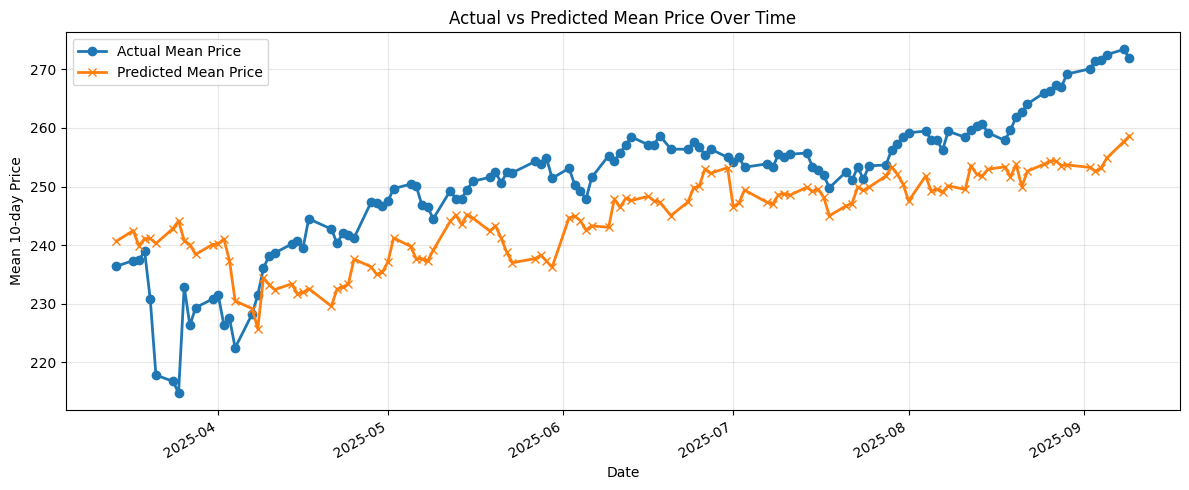

In [37]:
# %pip install joblib lightgbm scikit-learn matplotlib

import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- Paths ---
NOTEBOOK_DIR = Path.cwd()
try:
    OUT = OUTPUT_DIR  # if previously defined
except NameError:
    OUT = NOTEBOOK_DIR.parents[1] / "processed"

TEST_FILE = OUT / "test_timesplit.csv"

# Candidate artifact locations
CANDIDATE_DIRS = [
    OUT / "artifacts",
    NOTEBOOK_DIR.parents[1] / "backend" / "models" / "artifacts",
]

# Resolve model and feature files
MODEL_FILE = None
FEATURE_FILE = None
for d in CANDIDATE_DIRS:
    mf = d / "model_lightgbm_optuna.joblib"
    ff = d / "feature_columns.csv"
    ff_alt = d / "selected_feature_columns.csv"
    if mf.exists():
        MODEL_FILE = mf
    if ff.exists():
        FEATURE_FILE = ff
    if FEATURE_FILE is None and ff_alt.exists():
        FEATURE_FILE = ff_alt

if MODEL_FILE is None:
    raise FileNotFoundError("Could not locate model_lightgbm_optuna.joblib in candidate artifact folders.")

# --- Load test data ---
test_df = pd.read_csv(TEST_FILE)
if "lastTradedTime" in test_df.columns:
    test_df["lastTradedTime"] = pd.to_datetime(test_df["lastTradedTime"], errors="coerce")

# --- Load model ---
final_model = joblib.load(MODEL_FILE)

# --- Determine features ---
if FEATURE_FILE is not None:
    X_cols = pd.read_csv(FEATURE_FILE).squeeze("columns").tolist()
else:
    if hasattr(final_model, "feature_name_") and final_model.feature_name_ is not None:
        X_cols = list(final_model.feature_name_)
    elif hasattr(final_model, "booster_"):
        X_cols = list(final_model.booster_.feature_name())
    else:
        raise RuntimeError("Cannot determine feature names; provide feature_columns.csv or use a model exposing feature_name_ / booster_.feature_name().")

# --- Build arrays (ensure same order) ---
target = "y_10d_price"  # or "y_10d_log_return"
id_time_cols = ["id","name","symbol","lastTradedTime"]

missing_test = [c for c in X_cols if c not in test_df.columns]
if missing_test:
    raise KeyError(f"Test is missing required features: {missing_test}")

X_test = test_df[X_cols].to_numpy()
y_test = test_df[target].to_numpy()

# --- Predict ---
pred_test = final_model.predict(X_test)

# --- Metrics (version-safe RMSE) ---
mae = mean_absolute_error(y_test, pred_test)

try:
    # Prefer modern API when available (scikit-learn >= 1.4)
    from sklearn.metrics import root_mean_squared_error
    rmse = root_mean_squared_error(y_test, pred_test)
except Exception:
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))

r2 = r2_score(y_test, pred_test)

print({"MAE": float(mae), "RMSE": float(rmse), "R2": float(r2)})

# Optional: directional accuracy (MDA) if current price exists
if "price" in test_df.columns:
    eps = 1e-12
    true_ret = np.log((y_test + eps) / (test_df["price"].to_numpy() + eps))
    pred_ret = np.log((pred_test + eps) / (test_df["price"].to_numpy() + eps))
    dir_acc = float(np.mean(np.sign(true_ret) == np.sign(pred_ret)))
    print({"Directional_Accuracy": dir_acc})

# --- Save predictions ---
pred_out = test_df[id_time_cols + [target]].copy()
pred_out["pred_lgbm"] = pred_test
pred_csv = OUT / "test_predictions_lgbm_optuna.csv"
pred_out.to_csv(pred_csv, index=False)
print("Saved predictions to:", pred_csv)

# --- Plot Actual vs Predicted (daily mean across symbols) ---
if "lastTradedTime" in pred_out.columns:
    plot_df = pred_out.copy()
    plot_df["lastTradedTime"] = pd.to_datetime(plot_df["lastTradedTime"], errors="coerce")
    plot_df["date"] = plot_df["lastTradedTime"].dt.normalize()

    daily = (plot_df
             .groupby("date", as_index=False)[[target, "pred_lgbm"]]
             .mean(numeric_only=True)
             .rename(columns={target: "actual", "pred_lgbm": "pred"}))

    plt.figure(figsize=(12, 5))
    plt.plot(daily["date"], daily["actual"], marker="o", linewidth=2, label="Actual Mean Price")
    plt.plot(daily["date"], daily["pred"],   marker="x", linewidth=2, label="Predicted Mean Price")
    plt.title("Actual vs Predicted Mean Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Mean 10-day Price")
    plt.xticks(rotation=30, ha="right")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping plot: lastTradedTime not present in test file.")
